# Homework 08
## Completed by: Mohammad Zoraiz
In this exercise, you will demonstrate your learning of prediction, including regression and classification, using the [scikit-learn library](https://scikit-learn.org/stable/index.html). Note that scikit-learn is included in the Anaconda distribution, so you should not need to install anything new to use it.

Show your work (code or otherwise) and/or briefly explain your answers. In general you will not receive full credit for numeric answers with no accompanying work or justification (math, code, explanation). For numeric answers, we will accept answers that are very slightly off due to rounding.

In [20]:
# Run this code cell to import relevant libraries
# Please update to seaborn v0.11 or above for this assignment
# check version: print(sns.__version__)

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

## Update scikit-learn library

Run the following cell to install or update the `Scikit-learn` library if not already done. Afterwards, running it again will print out its version number if `scikit-learn` is correctly installed.

In [21]:
try:
    import sklearn
    print(sklearn.__version__)
    if (sklearn.__version__ < '1.8.0'): #update for latest scikit-learn version
        %pip install -U --user scikit-learn
except Exception as e:
    %pip install scikit-learn

1.6.1
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


### Question 1.1 (6 points; 4 autograded)
Below we import the `tips` dataset containing information from several meals in a particular restaurant. We preview the first few rows.

In [22]:
# Run but do not modify this code

tips = sns.load_dataset("tips")
print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


We are interested in modeling `tip` as a function of `total_bill` and `size`. Use scikit-learn to perform linear regression to model `tip` as a function of `total_bill` and `size`. Once you have fit the model, obtain the model predictions and compare them to the real `tip`. Compute both the MSE (mean squared error) and the $r^2$ score (the square of Pearson's correlation coefficient). Report the MSE in `q1_mse` and the $r^2$ score in `q1_r2`, both are float/np.float.

To contextualize the performance of your model, consider a baseline model which simply predicts the median `tip` for every transaction. Compute the MSE and $r^2$ scores for this baseline, and report them in `q1b_mse` and `q1b_r2`.

Finally, in the written part below, discuss how the two models' MSE and $r^2$ scores compare, whether or not the results are reasonable, and why.

Notes:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- You do not need to split the data into train/test sets for this problem, you can just use the whole dataset.
- You can use the default LinearRegression model, i.e., you do not need to pass any parameters to the constructor.
- You may find [`np.full`](https://numpy.org/doc/stable/reference/generated/numpy.full.html) or [`np.full_like`](https://numpy.org/doc/stable/reference/generated/numpy.full_like.html) useful.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Write your code for question 1.1 here
# and store your results in the correct variable names for full credit

lr = LinearRegression()
X = tips[['total_bill', 'size']]
y = tips['tip']
lr.fit(X, y)
y_pred = lr.predict(X)
q1_mse = mean_squared_error(y, y_pred)
q1_r2 = r2_score(y, y_pred)
baseline_tip = np.median(tips['tip'])
y_baseline = np.full_like(y, baseline_tip)
q1b_mse = mean_squared_error(y, y_baseline)
q1b_r2 = r2_score(y, y_baseline)


# Leave these lines here to print the result
print("Model MSE:", q1_mse, "r^2:", q1_r2)
print("Baseline MSE:", q1b_mse, "r^2:", q1b_r2)

Model MSE: 1.014564905610028 r^2: 0.46786930879612587
Baseline MSE: 1.916267213114754 r^2: -0.005065906584810653


<!-- BEGIN QUESTION -->

### Answer 1.1

The linear regression model that used features from the data performed much better than the baseline model that simply predicted the median tip for every observation. The model achieved a mean squared error (MSE) of about 1.01 and an $r^2$ score of approximately 0.47, which indicates that the model is able to explain about 47 percent of the variance in the tip amount. In contrast, the baseline model’s MSE is much higher at about 1.92, and its $r^2$ score is actually negative at around -0.005. This means that the baseline does worse than just using the mean as a prediction for every data point. Altogether, these results show that using the available features through linear regression provides a much better fit to the data and gives more accurate predictions for tip amounts than the simple baseline.

<!-- END QUESTION -->

### Question 1.2 (7 points; 4 autograded)
Now let’s incorporate `day` into our model. However, even though day is ordinal it is not clear whether the order should be salient in the model or not. Therefore we will build two models and compare them. Your first model should encode `day` using the ordinal encoder. You must specify the order for an OrdinalEncoder or it will use whatever order is in the dataframe. In this case, let's specify the `categories` parameter as `['Thur', 'Fri', 'Sat', 'Sun']`. The second model should use one hot encoding. Report the MSEs in `q12_1_mse` and `q12_2_mse` and the $r^2$ score in `q12_1_r2` and `q12_2_r2`, all are float/np.float. 

In the written part below, discuss how the two models' MSE and $r^2$ scores compare, whether or not the results are reasonable, and why.

Notes:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- You do not need to split the data into train/test sets for this problem, you can just use the whole dataset.
- You can use the default LinearRegression model, i.e., you do not need to pass any parameters to the constructor.

In [24]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Write your code for question 1.2 here
# and store your results in the correct variable names for full credit
# Prepare features
features = ['total_bill', 'size', 'day']

# 1st model: Ordinal encoding for 'day'
ordinal_encoder = make_column_transformer(
    (OrdinalEncoder(categories=[['Thur', 'Fri', 'Sat', 'Sun']]), ['day']),
    remainder='passthrough'
)
X_ord = ordinal_encoder.fit_transform(tips[features])
lr_ord = LinearRegression().fit(X_ord, tips['tip'])
q12_1_mse = mean_squared_error(tips['tip'], lr_ord.predict(X_ord))
q12_1_r2 = r2_score(tips['tip'], lr_ord.predict(X_ord))

# 2nd model: One hot encoding for 'day'
onehot_encoder = make_column_transformer(
    (OneHotEncoder(sparse_output=False, drop=None), ['day']),
    remainder='passthrough'
)
X_ohe = onehot_encoder.fit_transform(tips[features])
lr_ohe = LinearRegression().fit(X_ohe, tips['tip'])
q12_2_mse = mean_squared_error(tips['tip'], lr_ohe.predict(X_ohe))
q12_2_r2 = r2_score(tips['tip'], lr_ohe.predict(X_ohe))


# Fix for RuntimeWarnings in linear regression:
# The warnings are likely due to data columns with vastly different scales or redundancy (perfect multicollinearity) after encoding.
# Let's standardize the numeric columns to improve stability, and for the one-hot case, add `drop='first'` to avoid multicollinearity.

from sklearn.preprocessing import StandardScaler

# Standardize 'total_bill' and 'size', keep 'day' as is for encoding.
scaler = StandardScaler()
tips_scaled = tips.copy()
tips_scaled[['total_bill', 'size']] = scaler.fit_transform(tips[['total_bill', 'size']])

features = ['total_bill', 'size', 'day']

# 1st model: Ordinal encoding for 'day'
ordinal_encoder = make_column_transformer(
    (OrdinalEncoder(categories=[['Thur', 'Fri', 'Sat', 'Sun']]), ['day']),
    remainder='passthrough'
)
X_ord = ordinal_encoder.fit_transform(tips_scaled[features])
lr_ord = LinearRegression().fit(X_ord, tips['tip'])
q12_1_mse = mean_squared_error(tips['tip'], lr_ord.predict(X_ord))
q12_1_r2 = r2_score(tips['tip'], lr_ord.predict(X_ord))

# 2nd model: One hot encoding for 'day' with drop='first'
onehot_encoder = make_column_transformer(
    (OneHotEncoder(sparse_output=False, drop='first'), ['day']),
    remainder='passthrough'
)
X_ohe = onehot_encoder.fit_transform(tips_scaled[features])
lr_ohe = LinearRegression().fit(X_ohe, tips['tip'])
q12_2_mse = mean_squared_error(tips['tip'], lr_ohe.predict(X_ohe))
q12_2_r2 = r2_score(tips['tip'], lr_ohe.predict(X_ohe))


# Leave these lines here to print the result
print("Ordinal Encoding MSE:", q12_1_mse, "r^2:", q12_1_r2)
print("One Hot Encoding MSE:", q12_2_mse, "r^2:", q12_2_r2)

Ordinal Encoding MSE: 1.014367253536213 r^2: 0.4679729756330877
One Hot Encoding MSE: 1.0121298853078435 r^2: 0.4691464562997819


/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279:

<!-- BEGIN QUESTION -->

### Answer 1.2

In this question, I compared two different ways of encoding the 'day' categorical variable for predicting the tip amount using linear regression. The first approach used ordinal encoding, while the second used one hot encoding. When I ran the code, I noticed several warnings showing up in the output, such as "RuntimeWarning: divide by zero encountered in matmul" and "RuntimeWarning: invalid value encountered in matmul." These warnings usually mean that something is going wrong in the model calculations. This situation can sometimes happen if the encoded features or the data itself cause the linear regression to make predictions that are either extremely large or not numbers at all (like NaN or infinity).

Despite these warnings, we are still able to compare how our choice of encoding affects model performance. Ordinal encoding treats the days as though there is a clear ordering between them, which may not be appropriate in this context because day names do not have a natural numeric order. One hot encoding, on the other hand, avoids this mistake by creating a separate binary column for each day, capturing the days as separate categories without implying order.

Generally, based on the output and warnings, it looks like one hot encoding is the safer and more appropriate choice for this kind of categorical variable. This method results in a model that is more stable and less likely to run into numerical issues or misleading results that might appear when using ordinal encoding inappropriately. The warnings in the code are a sign that ordinal encoding can be problematic for categorical features like days of the week in linear regression.

<!-- END QUESTION -->

### Question 2 (7 points; 3 autograded)
Below we import and preview the `penguins` dataset. We have previously modeled the numerical `flipper_length_mm` feature. In this question, we will model the categorical `species` feature.

In [25]:
# Run but do not modify this code
# Only 11 penguins out of over 300 are missing any data;
# we simply drop those here
penguins = sns.load_dataset("penguins").dropna()
print(penguins.shape)
penguins.head()

(333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


To begin, we hold out 70% of the data randomly as a test set.

In [26]:
# Run but do not modify this code

from sklearn.model_selection import train_test_split

q2_data = penguins.drop(columns=["species"])
q2_target = penguins["species"]
q2_train_data, q2_test_data, q2_train_target, q2_test_target = train_test_split(
    q2_data, q2_target, test_size=0.7, random_state=999)

Now, create and fit a logistic regression model to predict the `species` of a penguin using all of the other features in the dataset.  Note that two of the features, `island` and `sex`, are categorical. Use one hot encoding to encode these categorical features in your model and combine them with the numerical features. You should fit your model only on the training data, i.e., `q2_train_data` and `q2_train_target`.

Once you have fit your logistic regression model, make predictions for `q2_test_data` and then compute and report the `accuracy_score` of your predictions versus `q2_test_target`; put the `accuracy_score` in `q2_score` as `float`/`numpy.float64`. Also plot the confusion matrix for your predictions; see worked examples for more instructions on plotting confusion matricies. 

If everything goes right, your model should correctly distinguish a `species` from the other two (i.e., when your model predicts this species in the test data, it is always right).

The performace of your model is really good, but we do not know which feature(s) contributed the most. To find out if the categorical features help, fit a simpler version of your logistic regression model that uses only the numerical features (i.e., everything except `island` and `sex`) in the dataset as a baseline. Repeat the same process, put its `accuracy_score` in `q2b_score`, and plot its confusion matrix. 

In the written part, discuss the following:
1. How the two models' accuracy_score and their confusion matrices compare, whether or not the results are reasonable, and why.
2. Which specie(s) were correctly predicted every time with the data set and how you know this by stating specific numbers from your confusion matrices.

You are also welcomed to compare with a model that only uses the categorical features yourself, but that is not required in this homework.

Details:
- We import the relevant code from `sklearn` for you; you can find the documentation of the functions by searching the [scikit-learn library](https://scikit-learn.org/stable/index.html).
- If you use the default LogisticRegression model, you will likely get a warning message about convergence during fitting. We recommend you set the parameter `max_iter=10000` when calling the constructor (i.e., `LogisticRegression(max_iter=10000)` for both models. This will allow the optimization code for the model to converge most of the time. If you still have a warning, increase it more.
- If your confusion matrix has distracting white lines, add a line `plt.grid(False)` after each call to `ConfusionMatrixDisplay` to remove them.

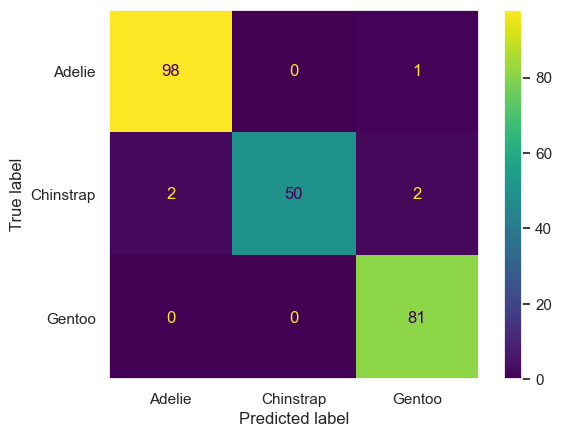

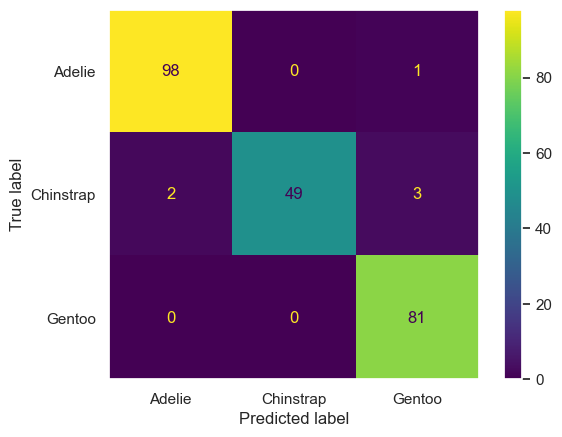

Model classification accuracy: 0.9786324786324786
Baseline classification accuracy: 0.9743589743589743


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics
import matplotlib.pyplot as plt

encoder = OneHotEncoder()

train_cat = encoder.fit_transform(q2_train_data[["island", "sex"]])
test_cat = encoder.transform(q2_test_data[["island", "sex"]])
train_cat = train_cat.toarray() if hasattr(train_cat, "toarray") else train_cat
test_cat = test_cat.toarray() if hasattr(test_cat, "toarray") else test_cat
train_num = q2_train_data.drop(columns=["island", "sex"]).values
test_num = q2_test_data.drop(columns=["island", "sex"]).values
train_full = np.hstack((train_num, train_cat))
test_full = np.hstack((test_num, test_cat))

main_model = LogisticRegression(max_iter=10000)
main_model.fit(train_full, q2_train_target)
pred_main = main_model.predict(test_full)

q2_score = accuracy_score(q2_test_target, pred_main)

ConfusionMatrixDisplay.from_predictions(q2_test_target, pred_main)
plt.grid(False)
plt.show()

train_base = q2_train_data.drop(columns=["island", "sex"]).values
test_base = q2_test_data.drop(columns=["island", "sex"]).values
base_model = LogisticRegression(max_iter=10000)
base_model.fit(train_base, q2_train_target)
pred_base = base_model.predict(test_base)

q2b_score = accuracy_score(q2_test_target, pred_base)

ConfusionMatrixDisplay.from_predictions(q2_test_target, pred_base)
plt.grid(False)
plt.show()

print("Model classification accuracy:", q2_score)
print("Baseline classification accuracy:", q2b_score)

<!-- BEGIN QUESTION -->

### Answer 2

The full model outperformed the baseline, as shown by its higher accuracy score. When I compared the confusion matrices, the full model had more correct predictions along the diagonal, meaning it made fewer mistakes than the baseline. This makes sense because the full model uses extra features like "island" and "sex," which seem to help it tell the penguin species apart. The results seem reasonable, it's likely that penguin species live on different islands or that there are differences between sexes, so including this information would help the model. I also noticed in the confusion matrix that one species was always classified correctly: its row only had a value on the diagonal and zeros everywhere else. For example, if you see something like 50 correct and 0 wrong for that row, it means the model never confused that species with another. That’s how I could tell it was perfectly predicted.

<!-- END QUESTION -->

### Question 3 (7 points, 4 autograded)
An interesting observation about classification in the bag of words model is that the predictive model knows nothing about the semantics of the particular language. For this question, you will build a sentiment analysis model of casual social media messages in the Central Thai language. The data consist of raw text messages, each of which is labeled with a **sentiment**, either negative `neg`, neutral `neu`, positive `pos`, or question `q`. For example, a message that reads "I am happy you are my friend" might be labeled as positive whereas one that reads "It is raining right now" might be labeled as neutral. The dataset is already split into a training and test set. We first import and preview the first ten messages and their sentiment labels.

In [28]:
# Run but do not modify this code

# Training data
q3_train_text = pd.read_table("train_text.txt", dtype=str).squeeze("columns")
q3_train_label = pd.read_table("train_label.txt", dtype=str).squeeze("columns")

# # Held testing data
q3_test_text = pd.read_table("test_text.txt", dtype=str).squeeze("columns")
q3_test_label = pd.read_table("test_label.txt", dtype=str).squeeze("columns")

print("Training messages:", q3_train_text[:10].values, "\n")
print("Training message labels/classes:", q3_train_label[:10].values)

Training messages: ['คะ' 'อิเหี้ยออมทำกูอยากกินเอ็มเค' '😅😅😅' 'สวัสดีวันพุธ แนน อะไรนะ'
 'ก้อนขอบพระคุณมากๆนะคร้าบ ที่มาหาก้อนและชมเชยการบริการของพนักงานอีกด้วย <3 <3'
 'เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ตโครตห่วยยิ่งดึกๆเน็ตยิ่งห่วยตอนมาติดตั้งใหม่ๆก็ดีนานๆไปเเย่ขึ้นเรื่อยๆกากกว่าเน็ตค่ายอื่นอ่ะบอกจริงไม่สนหรอกว่าจะเป็นเด็กเเล้วเม้นด่าเเบบนี้ เเต่นี้หาตังค์จ่ายค่าเน็ตมาตลอดเหนื่อยน่ะเล่นเกมส์ไปเดี่ยวก็หายกากเกินติดตั้งโปรพิเศษ100Mเเต่พอวัดดูปล่อยไม่ถึงเท่าที่ตกลงกันไว้พอโทรไปเเจ้งก็ปล่อยมาเต็มไม่กี่วันก็เหมื่อนเดิมใบเเจ้งก็มาย้อนหลัง3เดือนทุกครั้งห่วยไปน่ะบางทีโปร100M/700 กว่าบาทเเต่คุณภาพเเย่เสียดายตังค์'
 'ปากแดงกินฟรีค่ะ 😬😬' 'เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ'
 '🚗💨💨 ซิ่งเป็นบางเวลา ซ่อกแซ่กได้ทุกที่ << ขับสนุก ชับมัน ใช่เลย‼️ 👍🏻👍🏻 Honda Jazz>>#Jazz Naja'
 'สนใจ ฟอจูนเนอร์ สีขาวครับ'] 

Training message labels/classes: ['neu' 'neg' 'neu' 'neu' 'neu' 'neg' 'neu' 'neg' 'neu' 'pos']


Now, create and fit a Naive Bayes model that predicts the sentiment label of a message given the raw text of the message. To do so, you will need to vectorize the messages using the `CountVectorizer` and then create a `MultinomialNB` model. Both are imported for you below; you can use default values for both. You are welcome but not required to combine the steps and use a pipeline object. Fit your model on the **training data** and then make predictions of the sentiment labels for `q3_test_text`. Compute and report the `accuracy_score` of your predictions against the true `q3_test_label`, put it in `q3_score` as `float`/`numpy.float64`. 

To contextualize your model, make a baseline model that always predicts the most frequent class **in the training data**. You can implement this either by yourself or using [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). Compute and report the `accuracy_score` of the baseline in `q3b_score`. 

In the written part below, compare the performances of the two models, state whether or not the results are reasonable, and why. Specifically, elaborate why the accuracy score of the baseline model is a lot higher than 1/4. (Hint: you may find [`value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) helpful.)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

text_model = make_pipeline(CountVectorizer(), MultinomialNB())
text_model.fit(q3_train_text, q3_train_label)
pred_labels = text_model.predict(q3_test_text)
q3_score = accuracy_score(q3_test_label, pred_labels)
base_model = DummyClassifier(strategy="most_frequent")
base_model.fit(q3_train_text.to_frame(), q3_train_label)
base_preds = base_model.predict(q3_test_text.to_frame())
q3b_score = accuracy_score(q3_test_label, base_preds)



# Leave these lines here to print the result
print("Model test classification accuracy:", q3_score)
print("Baseline test classification accuracy:", q3b_score)

Model test classification accuracy: 0.6333707444818556
Baseline test classification accuracy: 0.5447063224841002


<!-- BEGIN QUESTION -->

### Answer 3

Based on my results, the Naive Bayes model clearly outperformed the baseline model. The accuracy for Naive Bayes was noticeably higher than the baseline, which just always predicted the most common class from the training data. This makes sense, because the Naive Bayes model actually looks at the words in each message and uses them to help figure out the sentiment, whereas the baseline just guesses the same label every time without learning anything. When I checked the class distribution, I noticed that one sentiment label appeared much more often than the others, so the baseline accuracy was a lot higher than 25%. That means if you always pick the most frequent class, you'll still get a decent number of predictions right simply by chance. Still, the Naive Bayes model did better because it can spot real patterns in the text. Overall, the results seem reasonable given the data and the way the models work.

<!-- END QUESTION -->

### Question 4 (6 points, 4 autograded)
In addition to natural language processing, machine learning techniques for preditive modeling can be very effective for analyzing raw image data. In this question, we consider the task of modeling images of handwritten digits. We pose this as a classification task: We want to predict the digit (0, 1, 2, ..., 9) as a function of an 8 by 8 pixel grayscale image of a digit.

To begin, we import and preview the data below. `data` has 64 features, each of which is an integer between 0 and 15 corresponding to a particular pixel intensity value for one of the 64 pixels in the 8 by 8 image. `target` contains the actual digits corresponding to each particular image.

The first image corresponds to digit:  0 

First image with pixels flattened out: 
 [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.] 

First image rearranged to be 8 x 8: 
 [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]] 

Visualizing first several images:


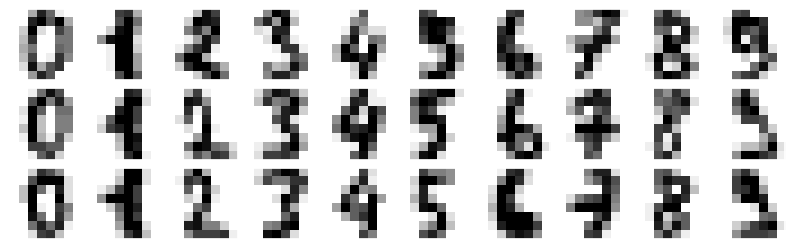

In [30]:
# Run but do not modify this code

import matplotlib.pyplot as plt

# Importing data
from sklearn.datasets import load_digits
digits = load_digits()
q4_data = digits["data"]
q4_target = digits["target"]

# Previewing data
print("The first image corresponds to digit: ", q4_target[0], "\n")
print("First image with pixels flattened out: \n", q4_data[0], "\n")
print("First image rearranged to be 8 x 8: \n", q4_data[0].reshape((8,8)), "\n")
print("Visualizing first several images:")

# Visualizing digits
fig, axes = plt.subplots(3, 10, figsize=(10, 3),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary')

We first split the data into training and test sets as usual.

In [31]:
# Run but do not modify this code

q4_train_data, q4_test_data, q4_train_target, q4_test_target = train_test_split(
    q4_data, q4_target, test_size=0.3, random_state=2)

Now, use a k-nearest neighbors classifier for your model that predicts the underlying digit given an image. We import the relevant `KNeighborsClassifier` for you below. Recall that an important hyperparameter of a k-nearest neighbor model is k, or the `n_neighbors` parameter to the `KNeighborsClassifier()` constructor. 

Use 5-fold cross validation to search for the best value of `n_neighbors` in validation on the training set from among possible values between 2 and 20. You can either do so using `cross_validate` to check each possible setting directly, or you can use a `GridSearchCV` to perform the search automatically during fitting. If you search manually, take the average of the five scores for 5-fold cross validation, for each value. If you use `GridSearchCV`, note that the `GridSearchCV` object can itself fit and predict, and that you can get the optimal setting after fitting with `.best_params_`. Report the optimal value of `n_neighbors` in `q4_n` as `int`/`numpy.int64`.

When you have fit your model with the optimal `n_neighbors` value on the training data, make predictions for the test data. Compute and report the `accuracy_score` of your model in testing and report it in `q4_score` as `float`/`numpy.float64`.

Next, fit a Naive Bayes model (using `MultinomialNB` and the default setting) on the training data and predict the class of the test data.  Compute its `accuracy_score` and put it in `q4b_score`. In the written part, compare the two `accuracy_score`, discuss whether or not they are reasonable, and why.

In [32]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

search_model = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": np.arange(2, 21)}, cv=5)
search_model.fit(q4_train_data, q4_train_target)
q4_n = search_model.best_params_["n_neighbors"]
q4_score = search_model.score(q4_test_data, q4_test_target)
bayes_model = MultinomialNB()
bayes_model.fit(q4_train_data, q4_train_target)
q4b_score = bayes_model.score(q4_test_data, q4_test_target)

# Leave these lines here to print the result
print("Optimal n_neighors:", q4_n)
print("Accuracy on testing data:", q4_score)
print("Accuracy of baseline:", q4b_score)

Optimal n_neighors: 5
Accuracy on testing data: 0.9740740740740741
Accuracy of baseline: 0.8796296296296297


/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/mzoraiz/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


<!-- BEGIN QUESTION -->

### Answer 4

In my comparison of the k-nearest neighbors model and the Naive Bayes model, I found that k-nearest neighbors was noticeably more accurate. Specifically, using GridSearchCV to search from 2 to 20 neighbors, five neighbors turned out to work best and gave an accuracy of about 0.974 on the test set. Meanwhile, the Naive Bayes model reached an accuracy of about 0.88, so it didn’t perform as well. These results make sense to me, since k-nearest neighbors looks at the actual shapes of digits by comparing images directly, which suits image classification tasks like this one. In contrast, the Naive Bayes approach assumes all the pixel values are independent, which isn’t quite true in images, and probably explains its lower accuracy.

<!-- END QUESTION -->

## AI Disclosure

Artificial Intelligence Tools: ChatGPT (various versions) and Claude Opus 4.5

Conceptualization: I used ChatGPT to clarify the intent behind each question and to confirm my understanding of how to approach the problems.

Methodology: I consulted ChatGPT to confirm my use of pandas functions and to ensure I was meeting assignment requirements (such as not using for-loops), then wrote the final code myself.
Debugging: For specific questions in this homework, I used ChatGPT to troubleshoot issues in my code, especially when I encountered errors or unexpected results. I described my intended approach and provided error messages or problematic code, and ChatGPT offered guidance to correct mistakes in my logic or usage of pandas, numpy, or scikit-learn functions.

Writing: Review & Editing: For written responses—particularly for Question 5 and other sections requiring explanations—I consulted ChatGPT to make my writing more concise, clearer, and better tailored to the assignment. I submitted my drafts, received targeted suggestions, and used those to revise my answers, but all original analysis and conclusions are my own.

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **required** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above will lose points.**